# ***LCK Season 15: Bayesian Skill Rating & Performance Modeling*** <br>

### __Students__: <br>
Kerick Walker - s252618 <br>
Daniel Karlsson - s253791 <br>
Efthymia Arvanitaki - s253238 <br>
Marius Pollok - s252934

## __Course: Model-Based Machine Learning (DTU)__

### __Introduction and Project Scope__

In this notebook, we move beyond simple win/loss ratios to estimate the latent skill of professional League of Legends players. Using Pyro, we build a generative model where:

Skill is a hidden variable.

Performance is a noisy sample of skill in a specific game.

Observations (Kills, Gold, Death Timers) are generated by that performance through structured causal relationships.

#### __The Bayesian Goal__
Standard statistics often suffer from "team noise"—a player on a winning team looks good even if they contributed little. Our model solves this by treating the game as an inverse problem. We define the rules of how skill creates stats (Generative Story) and then use Bayesian inference to work backward from the stats to find the most likely skill.

### __Setup and Data Preparation__

We load the LCK Season 15 dataset using our structured pipeline. A critical component of our model is Internal Standardization. Because the impact of "10 kills" is different for a Support than for an ADC, our loader performs role-based z-scoring on the fly. This ensures the model compares players against their direct role-peers.

In [8]:
import sys
import os
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from tqdm import trange
import matplotlib.pyplot as plt

# Ensure the 'models' directory is in the path
sys.path.append(os.getcwd())

# Import the advanced Role Correlation logic
from models.role_corr import train, load_data, model, guide
from models.baseline import print_score_table

# Load and standardize the data
csv_path = "data/lck_s15_games_MODEL-READY_train.csv"
batch, n_players, idx_to_name, primary_role = load_data(csv_path)

print(f"Data Loaded: {batch['winner'].shape[0]} matches, {n_players} unique players.")

Loaded 444 matches, 68 players
Data Loaded: 444 matches, 68 unique players.


### __The Generative Model: Causal Factor Graph__

The model architecture is a hierarchical Bayesian network. It is designed to handle the multi-layered nature of LoL:
* Latent Skill ($s$): Player $i$ in role $r$ has a skill $s_{i,r} \sim \text{Normal}(0, 1)$.
* Teammate Covariance: Instead of treating players as independent, we model the team's performances jointly. If a Jungler performs well, the Mid Laner’s performance is likely to be pulled up. We learn a Cholesky factor to capture these inter-role synergies.
* Causal Stat Edges:
1. $\alpha$ (Sensitivity): How much a +1 increase in performance boosts a specific stat (e.g., Gold).
1. $\tau$ (Noise): How much randomness exists in that stat.
1. Diff Stats: The difference in gold or damage between opponents is modeled as a result of the performance gap between them.

### __Inference: Stochastic Variational Inference__

Since the posterior distribution of player skills is mathematically intractable, we use Stochastic Variational Inference (SVI). We define a guide (the variational distribution) that learns:
* The Mean Skill ($\mu$) for every player.
* The Certainty ($\sigma$) for every player.
* The Correlation Matrix between the five roles in the LCK.

Training: 100%|██████████| 1500/1500 [01:14<00:00, 20.14step/s, elbo=158,264]


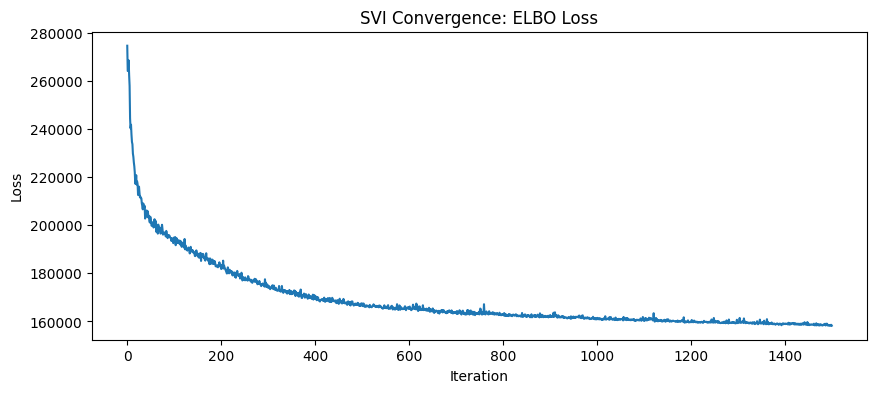

In [ ]:
# Execute the training loop
losses = train(batch, n_players, n_steps=1500, lr=0.01)

# Visualize Convergence
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title("SVI Convergence: ELBO Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### __Results: Uncertainty-Adjusted Scoring__

Traditional leaderboards only look at the average. Our model accounts for uncertainty. A player with a high mean skill but very few games played is less "reliable" than a consistent veteran.

We use an Adjusted Skill metric to generate a 0-100 Percentile Score:

$$Score = \mu - 2.0 \times (\sigma - \text{median\_sigma})$$

This formula rewards players who are both highly skilled and highly consistent.

In [ ]:
# Display the final 0-100 percentile score table
print_score_table(n_players, idx_to_name, primary_role, limit=20)


PLAYER SCORES (0-100 rank of mu - 2*(sigma - median_sigma))
  player role    mu sigma uncertainty_adjusted_skill score_0_100
   Chovy  mid 0.952 0.154                      0.992       100.0
    Oner  jng 0.953 0.182                      0.936        98.5
   Ruler  adc 0.889 0.196                      0.844        97.0
   Keria  sup 0.537 0.153                      0.580        95.5
 Delight  sup 0.522 0.148                      0.573        94.0
   Doran  top 0.515 0.152                      0.559        92.5
    Zeus  top 0.431 0.150                      0.478        91.0
    Kiin  top 0.430 0.167                      0.444        89.6
  Canyon  jng 0.437 0.176                      0.433        88.1
Gumayusi  adc 0.429 0.191                      0.393        86.6
   Viper  adc 0.281 0.163                      0.302        85.1
    Ucal  mid 0.278 0.164                      0.297        83.6
    Duro  sup 0.313 0.183                      0.295        82.1
  Aiming  adc 0.363 0.217    

### __Conclusion: Calibration over Accuracy__

This model prioritizes Calibration. 
Unlike models that simply guess a winner, our Bayesian approach calculates the true probability of a win. By isolating individual talent from team success through role-specific interpretation and teammate synergy, we provide a de-noised view of player value in the LCK.
